---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Основи радіоелектроніки. Частина 1"</h2></b></p>
<p style="text-align: center;"><b><h3>Тема 9. Трифазні кола</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Питання теми:</b></p>
<ul style="text-align: left;">
  <li>Трифазні кола. Схема «зірка» (PySpice)</li>
  <li>Векторні діаграми трифазних кіл</li>
  <li>З'єднання «зірка» та «трикутник»</li>
  <li>Співвідношення між лінійними та фазними напругами і струмами</li>
  <li>Три- та чотирипровідні схеми</li>
  <li>Симетричне та несиметричне навантаження. «Перекіс» фаз</li>
  <li>Особливості розрахунку трифазних кіл</li>
  <li>Потужності у трифазних колах змінного струму</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Тема 9 з 16</p>
</div>
    </th>
  </tr>
</table>

---


---

<p style="text-align: center;"><b>Зміст</b></p>

* [Трифазні кола. Схема «зірка» (PySpice)](#three-phase)
    * [Векторні діаграми трифазних кіл](#three-phase-vectors)
    * [З'єднання «зірка» та «трикутник»](#star-delta-3ph)
    * [Співвідношення між лінійними та фазними напругами і струмами](#three-phase-line-phase)
    * [Три- та чотирипровідні схеми](#three-four-wire)
    * [🔬 Інтерактивно: несиметрична зірка з нейтральним проводом і без нього](#star-neutral-interactive)
    * [Симетричне та несиметричне навантаження. «Перекіс» фаз](#phase-imbalance)
    * [Особливості розрахунку трифазних кіл](#three-phase-calc)
    * [Потужності у трифазних колах змінного струму](#three-phase-power)
* [📌 Підсумок курсу: Основи радіоелектроніки. Частина 1](#summary)
* [📚 Рекомендована література та ресурси](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*.

---

**Підключення бібліотек.** SymPy — символьні обчислення, NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice — моделювання схем, schemdraw — побудова схем. Тут же задано стиль графіків та умовні позначення елементів за ДСТУ. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import sympy as smp
from sympy import *
from sympy import symbols, Matrix
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник,
    # джерело ЕРС — коло зі стрілкою (напрямок дії ЕРС), джерело струму — коло з подвійною стрілкою
    from schemdraw.segments import Segment
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

---
## Трифазні кола. Схема «зірка» (PySpice) <a class="anchor" id="three-phase"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Описувати особливості трифазних схем (схема «зірка», «трикутник»)
> - Аналізувати розподіл напруг і струмів у симетричному та несиметричному режимах
> - Визначати струм нейтралі при незбалансованому навантаженні

</div>

**Трифазна система напруг (зміщення фаз 120°):**
$$u_1(t) = U_m \sin(\omega t), \quad u_2(t) = U_m \sin(\omega t - 120°), \quad u_3(t) = U_m \sin(\omega t - 240°)$$

Завдяки такому зміщенню при симетричному навантаженні струм нейтралі $I_n = 0$.

**Нижче:** інтерактивна PySpice-симуляція трифазної схеми зірка з можливістю зміни навантаження в кожній фазі.

In [2]:
def g(R1_sb, R2_sb, R3_sb, Rl_sb, F_sb):
    # Опис схеми (netlist)
    circuit = Circuit('Трифазна схема зірка')
    
    # крок і тривалість моделювання перехідного процесу
    steptime = 0.1@u_ms
    finaltime = 0.1

    circuit.SinusoidalVoltageSource('Vsin1', 'in1', circuit.gnd, offset=0, amplitude=100, delay = 0,        frequency=F_sb@u_Hz)
    circuit.SinusoidalVoltageSource('Vsin2', 'in2', circuit.gnd, offset=0, amplitude=100, delay = -1/F_sb/3, frequency=F_sb@u_Hz)
    circuit.SinusoidalVoltageSource('Vsin3', 'in3', circuit.gnd, offset=0, amplitude=100, delay = -2/F_sb/3, frequency=F_sb@u_Hz)

    circuit.R(1, 'in1', 'out1',  Rl_sb@u_Ω)
    circuit.R(2, 'in2', 'out2',  Rl_sb@u_Ω)
    circuit.R(3, 'in3', 'out3',  Rl_sb@u_Ω)

    circuit.R(4, 'out1', 'com',  R1_sb@u_kΩ)
    circuit.R(5, 'out2', 'com',  R2_sb@u_kΩ)
    circuit.R(6, 'out3', 'com',  R3_sb@u_kΩ)

    circuit.R(7, 'com', circuit.gnd,  1@u_Ω)

    print(circuit.models)
    # Моделювання перехідного процесу
    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    analysis = simulator.transient(step_time=steptime, end_time=finaltime)
    
    # ПОБУДОВА ГРАФІКІВ
    figure, (axe1, axe2, axe3, axe4) = plt.subplots(4, 1, figsize=(12, 7))
    
    axe1.set_title('Трифазна схема зірка')
    axe1.set_xlabel('Час [s]')
    axe1.set_ylabel('Вхідна напруга [V]')
    axe1.grid()
    plot(analysis['in1'], axis=axe1)
    plot(analysis['in2'], axis=axe1)
    plot(analysis['in3'], axis=axe1)
    axe1.set_ylim(-220, 220)  # межі осі для наочності
    axe1.legend(('Фаза 1','Фаза 2','Фаза 3'), loc=(.05, .1))
    cursor = Cursor(axe1, useblit=True, color='red', linewidth=1)

    axe2.set_xlabel('Час [s]')
    axe2.set_ylabel('Вихідна напруга [V]')
    axe2.grid()
    plot(analysis['out1']-analysis['com'], axis=axe2)
    plot(analysis['out2']-analysis['com'], axis=axe2)
    plot(analysis['out3']-analysis['com'], axis=axe2)
    axe2.set_ylim(-220, 220)  # межі осі для наочності
    axe2.legend(('Фаза 1','Фаза 2','Фаза 3'), loc=(.05, .1))
    cursor = Cursor(axe2, useblit=True, color='red', linewidth=1)
    
    axe3.set_title('')
    axe3.set_xlabel('Час [s]')
    axe3.set_ylabel('Струм [А]')
    axe3.grid()
    plot((analysis['out1']-analysis['com'])/R1_sb, axis=axe3)
    plot((analysis['out2']-analysis['com'])/R2_sb, axis=axe3)
    plot((analysis['out3']-analysis['com'])/R3_sb, axis=axe3)
    #axe2.set_ylim(-15, 15)  # межі осі для наочності
    axe3.legend(('Фаза 1','Фаза 2','Фаза 3'), loc=(.05, .1))
    cursor = Cursor(axe3, useblit=True, color='red', linewidth=1)

    axe4.set_title('')
    axe4.set_xlabel('Час [s]')
    axe4.set_ylabel('Струм [А]')
    axe4.grid()
    plot((analysis['com'])/1, axis=axe4)
    #axe2.set_ylim(-15, 15)  # межі осі для наочності
    axe4.legend(('Нуль'), loc=(.05, .1))
    cursor = Cursor(axe3, useblit=True, color='red', linewidth=1)


w = interactive(g,
                {'manual': True},
                R1_sb=widgets.IntSlider(min=1, max=50, step=1, value=4, description ='$R_{1}, [Ohm]$'),
                R2_sb=widgets.IntSlider(min=1, max=50, step=1, value=4, description ='$R_{2}, [Ohm]$'),
                R3_sb=widgets.IntSlider(min=1, max=50, step=1, value=4, description ='$R_{3}, [Ohm]$'),
                Rl_sb=widgets.IntSlider(min=1, max=50, step=1, value=4, description ='$R_{l}, [Ohm]$'),
                F_sb=widgets.IntSlider(min=1, max=100, step=1, value=50, description ='$F_{sw}, [kHz]$')
               )
display(w)

interactive(children=(IntSlider(value=4, description='$R_{1}, [Ohm]$', max=50, min=1), IntSlider(value=4, desc…

### ⚡ Практичне застосування: Трифазні системи

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Трифазну систему передачі енергії запропонував Нікола Тесла у 1888 р., і вона стала світовим стандартом:

- **Промислові двигуни:** трифазні асинхронні двигуни працюють завдяки обертовому магнітному полю, яке створюється саме зсувом фаз на 120°.
- **Розподільні мережі:** лінії 6/10/35/110 кВ передають енергію трьома проводами замість шести — економія провідника без втрати потужності.
- **Побутова мережа:** у під'їздах багатоквартирних будинків підводяться усі три фази (380 В лінійна), а в кожну квартиру — одна фаза (220 В).


</div>


---
### Векторні діаграми трифазних кіл <a class="anchor" id="three-phase-vectors"></a>

Симетрична система фазних напруг зручно зображується векторами (фазорами) однакової довжини $U_ф$, розведеними на $120°$:

$$\dot U_A = U_ф, \qquad \dot U_B = U_ф e^{-j120°}, \qquad \dot U_C = U_ф e^{-j240°} = U_ф e^{j120°}$$

**Лінійна напруга** — різниця відповідних фазних векторів, наприклад $\dot U_{AB} = \dot U_A - \dot U_B$. Геометрично це діагональ ромба, побудованого на векторах $\dot U_A$ і $-\dot U_B$; за теоремою косинусів для кута $120°$ між ними:

$$U_{AB} = \sqrt{U_A^2+U_B^2-2U_AU_B\cos120°} = U_ф\sqrt3$$

При цьому вектор $\dot U_{AB}$ випереджає $\dot U_A$ на $30°$.


Побудуємо векторну діаграму фазних напруг $U_A$, $U_B$, $U_C$ та лінійних напруг як їх різниць:

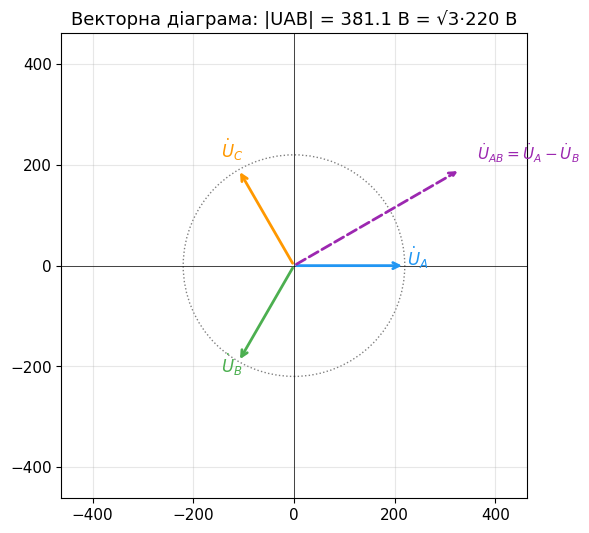

In [3]:
# Векторна діаграма фазних і лінійних напруг
Uf = 220.0
angles = np.array([0, -120, -240]) * np.pi/180
UA, UB, UC = [Uf*np.exp(1j*a) for a in angles]
UAB = UA - UB

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'aspect': 'equal'})
for U, name, color in [(UA, '$\\dot U_A$', '#2196F3'), (UB, '$\\dot U_B$', '#4CAF50'),
                        (UC, '$\\dot U_C$', '#FF9800')]:
    ax.annotate('', xy=(U.real, U.imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.text(U.real*1.12, U.imag*1.12, name, color=color, fontsize=12, ha='center')

ax.annotate('', xy=(UAB.real, UAB.imag), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#9C27B0', lw=2, ls='--'))
ax.text(UAB.real*1.1, UAB.imag*1.1, '$\\dot U_{AB}=\\dot U_A-\\dot U_B$', color='#9C27B0', fontsize=11)

circle = plt.Circle((0, 0), Uf, fill=False, ls=':', color='gray')
ax.add_patch(circle)
lim = Uf*2.1
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_title(f'Векторна діаграма: |UAB| = {abs(UAB):.1f} В = √3·{Uf:.0f} В')
plt.tight_layout(); plt.show()


---
### З'єднання «зірка» та «трикутник» <a class="anchor" id="star-delta-3ph"></a>

| | Зірка (Y) | Трикутник (Δ) |
|---|-----------|----------------|
| **Схема** | Три фазні вітки з'єднуються в одну спільну точку (нейтраль $N$), вільні кінці — лінійні виводи | Кінець кожної фазної вітки з'єднується з початком наступної, утворюючи замкнений контур; лінійні виводи — у точках з'єднання |
| **Напруга на фазній вітці** | Фазна напруга $U_ф$ (між лінійним виводом і нейтраллю) | Лінійна напруга $U_л$ (безпосередньо між двома лінійними виводами) |
| **Струм у фазній вітці** | Дорівнює лінійному струму | Менший за лінійний струм у $\sqrt3$ разів |
| **Нейтральна точка** | Є (можна вивести четвертий провід) | Відсутня |
| **Типове застосування** | Розподільні мережі, обмотки генераторів/трансформаторів, де потрібна нейтраль | Обмотки двигунів, силові трансформатори, там де нейтраль не потрібна |


Схеми з'єднання трифазного навантаження «зірка» та «трикутник»:

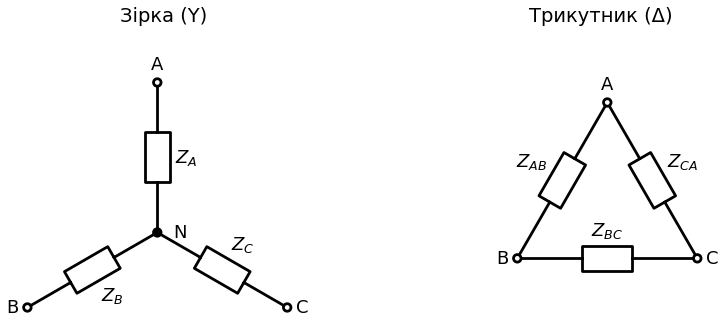

In [4]:
# Schemdraw: з'єднання «зірка» і «трикутник» для трифазного навантаження
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=3) as d:
        # зірка: три опори від спільної точки N до затискачів A, B, C
        N = d.add(elm.Dot().at((0, 0)).label('N', loc='right', ofst=0.25))
        za = d.add(elm.Resistor().at(N.center).theta(90).label('$Z_A$', loc='bottom'))
        d.add(elm.Dot(open=True).label('A', loc='top'))
        zb = d.add(elm.Resistor().at(N.center).theta(210).label('$Z_B$', loc='bottom'))
        d.add(elm.Dot(open=True).label('B', loc='left'))
        zc = d.add(elm.Resistor().at(N.center).theta(330).label('$Z_C$', loc='top'))
        d.add(elm.Dot(open=True).label('C', loc='right'))
        d.add(elm.Label().at((0, 4.3)).label('Зірка (Y)', fontsize=14))

        # трикутник: опори між парами лінійних затискачів
        s = 3.6
        A = (9, 2.6); B = (9 - s/2, 2.6 - s*0.866); C = (9 + s/2, 2.6 - s*0.866)
        d.add(elm.Resistor().at(A).to(B).label('$Z_{AB}$', loc='top'))
        d.add(elm.Resistor().at(B).to(C).label('$Z_{BC}$', loc='top'))
        d.add(elm.Resistor().at(C).to(A).label('$Z_{CA}$', loc='top'))
        d.add(elm.Dot(open=True).at(A).label('A', loc='top'))
        d.add(elm.Dot(open=True).at(B).label('B', loc='left'))
        d.add(elm.Dot(open=True).at(C).label('C', loc='right'))
        d.add(elm.Label().at((9, 4.3)).label('Трикутник (Δ)', fontsize=14))
else:
    print('Встановіть schemdraw: pip install schemdraw')

---
### Співвідношення між лінійними та фазними напругами і струмами <a class="anchor" id="three-phase-line-phase"></a>

| | Зірка | Трикутник |
|---|-------|-----------|
| Напруга | $U_л = \sqrt3\, U_ф$ | $U_л = U_ф$ |
| Струм | $I_л = I_ф$ | $I_л = \sqrt3\, I_ф$ |

Для трикутника співвідношення струмів отримують так само, як лінійні напруги для зірки — з рівнянь KCL у вершинах трикутника: лінійний струм є різницею двох фазних струмів, зсунутих на $120°$ ($\dot I_A = \dot I_{AB}-\dot I_{CA}$), що за тією ж геометрією дає множник $\sqrt3$.

> Побутова мережа: $U_ф=220$ В (фазна, зірка) → $U_л=380$ В (лінійна). Промислові трифазні двигуни на табличці часто вказують «Δ/Y 220/380 В» — обмотки можна перемкнути на трикутник (нижча лінійна напруга витримується кожною обмоткою) або зірку (вища) залежно від мережі.


---
### Три- та чотирипровідні схеми <a class="anchor" id="three-four-wire"></a>

| Схема | Коли застосовується |
|-------|----------------------|
| **Трипровідна** (без нейтралі) | З'єднання трикутником (нейтралі немає за означенням); або зірка з **завідомо симетричним** навантаженням (наприклад, трифазний двигун) — нейтраль не потрібна, оскільки струми й так врівноважені; типова для ліній високої напруги (економія одного провідника) |
| **Чотирипровідна** (зірка з нейтраллю) | Зірка з **потенційно несиметричним** навантаженням — типова для розподільних мереж 0,4 кВ, що живлять однофазних споживачів (квартири, освітлення). Нейтральний провід відводить різницевий (неврівноважений) струм і утримує фазні напруги збалансованими незалежно від навантаження в кожній фазі |

Провід нейтралі в чотирипровідній схемі зазвичай не мають запобіжника і не комутують — його розрив (аварійний обрив) перетворює схему на трипровідну з наслідками, описаними нижче.


---
### 🔬 Інтерактивно: несиметрична зірка з нейтральним проводом і без нього <a class="anchor" id="star-neutral-interactive"></a>

<div style="background-color: #f5f3ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #7c3aed; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Задайте опори фаз навантаження $R_A, R_B, R_C$ і ввімкніть/вимкніть нейтральний провід. З нейтраллю напруги на фазах навантаження дорівнюють фазним напругам генератора, а в нейтралі тече струм $\dot I_N = \dot I_A + \dot I_B + \dot I_C$. Без нейтралі з'являється **напруга зміщення нейтралі** $\dot U_{nN} = \dfrac{\sum \dot E_k Y_k}{\sum Y_k}$ і фазні напруги навантаження стають різними — «перекіс фаз».

</div>

In [5]:
# Інтерактивно: несиметрична зірка з нейтральним проводом і без нього
def star_neutral_interactive(R_A=22.0, R_B=44.0, R_C=110.0, neutral=True):
    Uf = 220.0                                   # діюче значення фазної напруги генератора, В
    a = np.exp(-2j*np.pi/3)                      # оператор повороту на -120°
    E = Uf*np.array([1, a, a**2])                # фазні ЕРС генератора
    Y = 1/np.array([R_A, R_B, R_C])              # провідності фаз навантаження
    U_nN = 0 if neutral else np.sum(E*Y)/np.sum(Y)   # напруга зміщення нейтралі
    U_load = E - U_nN                            # фазні напруги на навантаженні
    I_ph = U_load*Y                              # фазні (= лінійні) струми
    I_N = I_ph.sum()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))
    colors = ['tab:red', 'tab:green', 'tab:blue']
    for k, name in enumerate('ABC'):
        ax1.annotate('', xy=(E[k].real, E[k].imag), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=colors[k], alpha=0.35, lw=1.5, ls='--'))
        ax1.annotate('', xy=(E[k].real, E[k].imag), xytext=(np.real(U_nN), np.imag(U_nN)),
                     arrowprops=dict(arrowstyle='->', color=colors[k], lw=2.2))
        ax1.text(1.22*E[k].real, 1.12*E[k].imag, f'$U_{name}$ = {abs(U_load[k]):.0f} В',
                 color=colors[k], ha='center', va='center')
    ax1.plot(0, 0, 'ko'); ax1.text(-30, -30, 'N', fontweight='bold')
    ax1.plot(np.real(U_nN), np.imag(U_nN), 'ms', ms=8)
    if not neutral:
        ax1.text(np.real(U_nN) + 8, np.imag(U_nN) + 8, f'n: $U_{{nN}}$ = {abs(U_nN):.0f} В', color='m')
    ax1.set_aspect('equal'); ax1.set_xlim(-300, 300); ax1.set_ylim(-280, 280)
    ax1.set_title('Векторна діаграма напруг (пунктир — ЕРС генератора)')

    labels = ['$I_A$', '$I_B$', '$I_C$', '$I_N$']
    vals = [abs(x) for x in I_ph] + [abs(I_N)]
    ax2.bar(labels, vals, color=colors + ['gray'])
    for x, v in enumerate(vals):
        ax2.text(x, v, f'{v:.2f} А', ha='center', va='bottom')
    ax2.set_ylabel('Діюче значення струму, А')
    ax2.set_title('Чотирипровідна схема' if neutral else 'Трипровідна схема (нейтраль відсутня)')
    plt.tight_layout(); plt.show()

interact(star_neutral_interactive,
         R_A=widgets.FloatSlider(value=22, min=5, max=200, step=1, description='R_A, Ом'),
         R_B=widgets.FloatSlider(value=44, min=5, max=200, step=1, description='R_B, Ом'),
         R_C=widgets.FloatSlider(value=110, min=5, max=200, step=1, description='R_C, Ом'),
         neutral=widgets.Checkbox(value=True, description='Нейтральний провід'));

interactive(children=(FloatSlider(value=22.0, description='R_A, Ом', max=200.0, min=5.0, step=1.0), FloatSlide…

---
### Симетричне та несиметричне навантаження. «Перекіс» фаз <a class="anchor" id="phase-imbalance"></a>

**Симетричне навантаження** — опори (повні опори) усіх трьох фаз однакові $Z_A=Z_B=Z_C$. Тоді лінійні струми рівні за модулем і зсунуті на $120°$, а їхня векторна сума (струм нейтралі) дорівнює нулю: $\dot I_N = \dot I_A+\dot I_B+\dot I_C=0$ — нейтральний провід у 4-провідній зірці можна подумки прибрати, на роботу схеми це не вплине.

**Несиметричне навантаження** — $Z_A \ne Z_B \ne Z_C$. У **чотирипровідній** зірці нейтральний провід (з малим опором) утримує потенціал нейтралі навантаження рівним потенціалу нейтралі джерела — фазні напруги на навантаженні залишаються практично незмінними, а нескомпенсований струм $\dot I_N \ne 0$ протікає саме нейтраллю.

Якщо ж нейтральний провід **відсутній або обірваний** (трипровідна зірка з несиметричним навантаженням), нейтральна точка навантаження $N'$ зміщується відносно нейтралі джерела. За методом вузлових потенціалів (теорема Мілмана) для вузла $N'$:

$$\dot \varphi_{N'} = \dfrac{\dot U_A Y_A + \dot U_B Y_B + \dot U_C Y_C}{Y_A+Y_B+Y_C}$$

Це і є **«перекіс» фаз**: напруги на окремих фазах навантаження $\dot U_A' = \dot U_A - \dot\varphi_{N'}$ тощо стають різними за модулем — одні фази отримують знижену напругу, інші — підвищену (аж до недопустимих значень), що є типовою аварійною ситуацією при обриві нульового провідника в побутовій мережі 0,4 кВ.


Без нейтралі (обрив):
  |UA_load|=191.2 В, |UB_load|=191.2 В, |UC_load|=314.3 В  (номінал 220 В)
  Зміщення нейтралі |phi_N| = 94.3 В


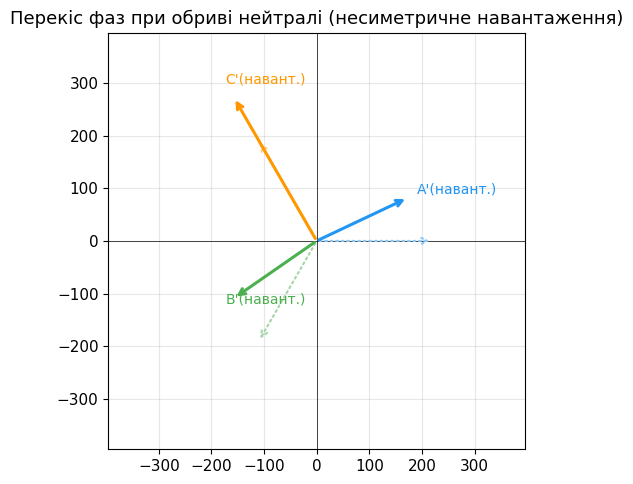

In [6]:
# Ілюстрація "перекосу" фаз при обриві нейтралі (несиметричне навантаження, 3-провідна зірка)
Uf2 = 220.0
angs = np.array([0, -120, -240]) * np.pi/180
UA2, UB2, UC2 = [Uf2*np.exp(1j*a) for a in angs]

# несиметричне навантаження (тільки активні опори)
ZA, ZB, ZC = 20.0, 20.0, 200.0    # фаза C сильно недовантажена (великий опір)
YA, YB, YC = 1/ZA, 1/ZB, 1/ZC

phi_N = (UA2*YA + UB2*YB + UC2*YC) / (YA+YB+YC)   # зміщення нейтралі
UA_load = UA2 - phi_N
UB_load = UB2 - phi_N
UC_load = UC2 - phi_N

print('Без нейтралі (обрив):')
print(f'  |UA_load|={abs(UA_load):.1f} В, |UB_load|={abs(UB_load):.1f} В, |UC_load|={abs(UC_load):.1f} В  (номінал {Uf2:.0f} В)')
print(f'  Зміщення нейтралі |phi_N| = {abs(phi_N):.1f} В')

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'aspect': 'equal'})
for U, name, color in [(UA2, 'A (джерело)', '#90caf9'), (UB2, 'B (джерело)', '#a5d6a7'), (UC2, 'C (джерело)', '#ffcc80')]:
    ax.annotate('', xy=(U.real, U.imag), xytext=(0, 0), arrowprops=dict(arrowstyle='->', color=color, lw=1.5, ls=':'))
for U, name, color in [(UA_load, "A'(навант.)", '#2196F3'), (UB_load, "B'(навант.)", '#4CAF50'), (UC_load, "C'(навант.)", '#FF9800')]:
    ax.annotate('', xy=(U.real, U.imag), xytext=(0, 0), arrowprops=dict(arrowstyle='->', color=color, lw=2.2))
    ax.text(U.real*1.1, U.imag*1.1, name, color=color, fontsize=10)
lim = Uf2*1.8
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_title("Перекіс фаз при обриві нейтралі (несиметричне навантаження)")
plt.tight_layout(); plt.show()


---
### Особливості розрахунку трифазних кіл <a class="anchor" id="three-phase-calc"></a>

| Ситуація | Підхід до розрахунку |
|----------|----------------------|
| Симетричне навантаження (будь-яка схема) | Достатньо розрахувати **одну фазу** (як звичайне однофазне коло символічним методом); значення для двох інших фаз отримують поворотом на $\mp120°$ — «розрахунок на одну фазу» |
| Несиметрична зірка з нейтраллю (мала $Z_N$) | Фазні напруги на навантаженні практично не змінюються — кожну фазу можна розраховувати незалежно, як три окремих однофазних кола |
| Несиметрична зірка без нейтралі (або з великим $Z_N$) | Потрібне зміщення нейтралі за теоремою Мілмана (окремий випадок методу вузлових потенціалів для одного вузла), після чого — напруги на кожній фазі навантаження |
| Несиметричний трикутник | Фазні (вони ж лінійні) напруги задані джерелом незалежно від навантаження; фазні струми знаходять за законом Ома окремо для кожної вітки, лінійні струми — за I законом Кірхгофа у вершинах |
| Змішані з'єднання, довільна несиметрія | Загальні методи — контурних струмів чи вузлових потенціалів, з переведенням «трикутник ⇄ зірка» (див. розділ «Метод еквівалентного генератора») для спрощення топології |


---
### Потужності у трифазних колах змінного струму <a class="anchor" id="three-phase-power"></a>

Для **симетричного** навантаження активна, реактивна та повна потужності трифазної системи — це потужності однієї фази, помножені на три (або виражені через лінійні величини):

$$P = 3U_ф I_ф\cos\varphi = \sqrt3\,U_л I_л\cos\varphi, \qquad Q = 3U_ф I_ф\sin\varphi = \sqrt3\,U_л I_л\sin\varphi, \qquad S=\sqrt{P^2+Q^2}=3U_фI_ф=\sqrt3\,U_лI_л$$

де $\varphi$ — кут зсуву фаз між фазною напругою і фазним струмом (однаковий для всіх трьох фаз при симетрії).

**Важлива властивість симетричної трифазної системи:** миттєва потужність $p(t)=p_A(t)+p_B(t)+p_C(t)$ — **стала**, не пульсує (на відміну від однофазного кола, де $p(t)$ містить складову подвоєної частоти). Це головна практична перевага трифазних систем: обертовий момент трифазного двигуна рівномірний, без вібрацій, пов'язаних із пульсацією потужності.

Для **несиметричного** навантаження такого спрощення немає — сумарну потужність рахують як суму потужностей окремих фаз:

$$P = U_A I_A\cos\varphi_A + U_B I_B\cos\varphi_B + U_C I_C\cos\varphi_C$$


Перевіримо чисельно: сума миттєвих потужностей трьох фаз симетричної системи стала в часі і дорівнює $3UI\cos\varphi$.

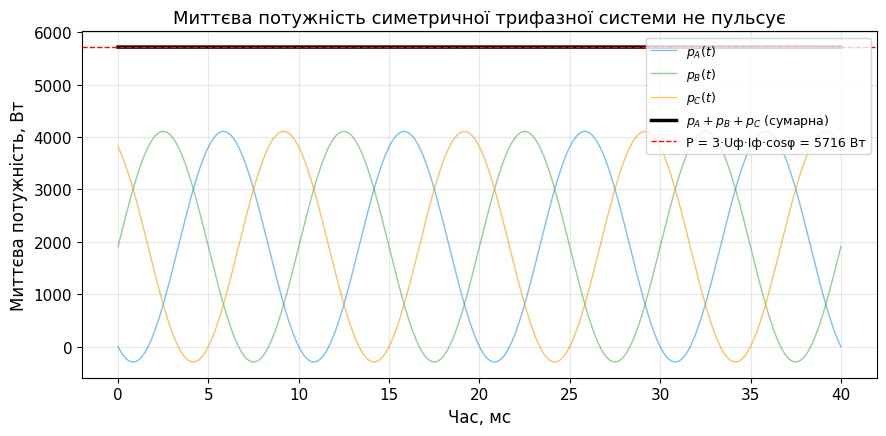

In [7]:
# Демонстрація: миттєва потужність симетричної трифазної системи стала (не пульсує)
Um3, Im3, f3 = 220*np.sqrt(2), 10*np.sqrt(2), 50.0
w3 = 2*np.pi*f3
phi_load = np.radians(30)   # кут навантаження, однаковий для всіх фаз
t3 = np.linspace(0, 2/f3, 2000)

pA = Um3*np.sin(w3*t3) * Im3*np.sin(w3*t3 - phi_load)
pB = Um3*np.sin(w3*t3-2*np.pi/3) * Im3*np.sin(w3*t3-2*np.pi/3 - phi_load)
pC = Um3*np.sin(w3*t3+2*np.pi/3) * Im3*np.sin(w3*t3+2*np.pi/3 - phi_load)
p_total = pA + pB + pC

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t3*1e3, pA, '#2196F3', lw=1, alpha=0.6, label='$p_A(t)$')
ax.plot(t3*1e3, pB, '#4CAF50', lw=1, alpha=0.6, label='$p_B(t)$')
ax.plot(t3*1e3, pC, '#FF9800', lw=1, alpha=0.6, label='$p_C(t)$')
ax.plot(t3*1e3, p_total, '#000000', lw=2.5, label='$p_A+p_B+p_C$ (сумарна)')
P_expected = 3 * (Um3/np.sqrt(2)) * (Im3/np.sqrt(2)) * np.cos(phi_load)
ax.axhline(P_expected, color='red', ls='--', lw=1, label=f'P = 3·Uф·Iф·cosφ = {P_expected:.0f} Вт')
ax.set_xlabel('Час, мс'); ax.set_ylabel('Миттєва потужність, Вт')
ax.set_title('Миттєва потужність симетричної трифазної системи не пульсує')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout(); plt.show()


---
### ⚡ Практичне застосування: Трифазні кола

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

- **Трифазні асинхронні двигуни** — стала (без пульсацій) миттєва потужність і обертове магнітне поле, створене зсувом фаз на $120°$, забезпечують рівномірний обертовий момент без додаткових пускових пристроїв.
- **Розподільні мережі 6/10/35/110 кВ** — трипровідні лінії (без нейтралі, часто з'єднання трикутником або із заземленою нейтраллю лише на підстанціях) економлять провідник порівняно з трьома незалежними однофазними лініями.
- **Побутова мережа 0,4 кВ** — обов'язково чотирипровідна (з нульовим провідником), оскільки однофазні споживачі в різних квартирах створюють істотно несиметричне навантаження; обрив нульового провідника — поширена й небезпечна аварія («перекіс фаз»), здатна вивести з ладу побутову техніку через підвищення напруги на недовантаженій фазі.

</div>

---
### ✅ Питання для самоперевірки: Трифазні кола

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому при симетричному навантаженні струм нейтралі дорівнює нулю?</summary>

> **Відповідь:** Три фазних струми рівні за амплітудою і зсунуті на 120°: $I_1+I_2+I_3 = I_m(\sin\omega t+\sin(\omega t-120°)+\sin(\omega t-240°))=0$ (тригонометрична тотожність, векторна сума трьох рівних векторів під 120° дорівнює нулю).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Яка лінійна напруга відповідає фазній у схемі зірка? А у трикутнику?</summary>

> **Відповідь:** Зірка: $U_л=\sqrt3\,U_ф$ (для мережі 220 В фазної — 380 В лінійна). Трикутник: $U_л=U_ф$ — лінійна і фазна напруги збігаються, бо кожна фазна обмотка ввімкнена безпосередньо між двома лінійними виводами.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому в трикутнику лінійний струм у √3 разів більший за фазний?</summary>

> **Відповідь:** Лінійний струм у вершині трикутника дорівнює векторній різниці двох фазних струмів сусідніх віток, зсунутих на 120° (за I законом Кірхгофа). Як і для лінійних напруг зірки, геометрія трикутника векторів під 120° дає множник √3.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Чим трипровідна схема відрізняється від чотирипровідної і коли яка потрібна?</summary>

> **Відповідь:** Чотирипровідна (зірка з нейтраллю) потрібна, коли навантаження може бути несиметричним (наприклад, розподіл на однофазних споживачів) — нейтраль відводить неврівноважений струм і зберігає фазні напруги стабільними. Трипровідна схема достатня для симетричного навантаження або для з'єднання трикутником, де нейтралі немає за означенням.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 5.</b> Що станеться з фазними напругами навантаження при обриві нульового провідника й несиметричному навантаженні?</summary>

> **Відповідь:** Нейтральна точка навантаження зміститься відносно нейтралі джерела (зміщення обчислюється за теоремою Мілмана), внаслідок чого фазні напруги стануть несиметричними — на одних фазах вони підвищаться, на інших знизяться. Це і називають «перекосом» фаз.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 6.</b> Як розрахувати симетричне трифазне коло найпростіше?</summary>

> **Відповідь:** Достатньо розрахувати струми й напруги для однієї фази звичайним символічним методом, а результати для двох інших фаз отримати простим поворотом комплексних величин на $\mp120°$ — завдяки симетрії повторювати розрахунок для кожної фази окремо не потрібно.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 7.</b> Чому миттєва потужність симетричної трифазної системи не пульсує, на відміну від однофазної?</summary>

> **Відповідь:** Миттєва потужність кожної фази містить сталу складову і складову подвоєної частоти. При підсумовуванні трьох фаз, зсунутих на 120°, складові подвоєної частоти трьох фаз взаємно компенсуються (їхня векторна сума на частоті $2\omega$ дорівнює нулю так само, як сума трьох напруг на частоті $\omega$), залишається лише стала сумарна активна потужність $P=3U_фI_ф\cos\varphi$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 8.</b> Трифазний двигун (симетричне навантаження) має Uл=380 В, Iл=10 А, cosφ=0,85. Яка активна потужність?</summary>

> **Відповідь:** $P=\sqrt3\,U_л I_л\cos\varphi = 1{,}732\cdot380\cdot10\cdot0{,}85 \approx 5591$ Вт $\approx 5{,}6$ кВт.

</details>

---
### 📝 Задачі для самостійного розв'язання: Трифазні кола


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Симетричне навантаження $\underline Z = 17{,}6 + j13{,}2$ Ом ($|\underline Z| = 22$ Ом, $\cos\varphi = 0{,}8$) з'єднане зіркою і живиться від мережі з лінійною напругою 380 В. Знайдіть фазну напругу, струм, $P$, $Q$ і $S$.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $U_ф = 380/\sqrt3 \approx 219{,}4$ В; $I_л = I_ф \approx 9{,}97$ А; $P = \sqrt3U_лI_л\cos\varphi \approx 5{,}25$ кВт; $Q \approx 3{,}94$ квар; $S \approx 6{,}56$ кВ·А.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Три резистори по 38 Ом живляться від мережі 380 В. Порівняйте струми і потужність при з'єднанні трикутником і зіркою.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> Трикутник: $I_ф = 10$ А, $I_л = 10\sqrt3 \approx 17{,}3$ А, $P = 11{,}4$ кВт. Зірка: $I = 219{,}4/38 \approx 5{,}77$ А, $P = 3{,}8$ кВт — утричі менше (на цьому ґрунтується пуск двигунів перемиканням «зірка → трикутник»).

</details>

---

## 📌 Підсумок курсу: Основи радіоелектроніки. Частина 1 <a class="anchor" id="summary"></a>

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

### Зведена таблиця методів розрахунку електричних кіл постійного струму

| Метод | Невідомі | Кількість рівнянь | Переваги |
|-------|---------|-------------------|---------|
| **Закони Кірхгофа** | Струми гілок $I_k$ | $m$ | Універсальний, прямолінійний |
| **Вузлових потенціалів** | Потенціали вузлів $\varphi_i$ | $n-1$ | Ефективний для паралельних кіл |
| **Контурних струмів** | Контурні струми $I_{ii}$ | $m-n+1$ | Ефективний для послідовних кіл |
| **Еквівалентного генератора** | $E_{ek}$, $R_{ek}$ | — | Аналіз навантажувальних характеристик |
| **Накладення** | Парціальні струми | — | Лінійні кола з кількома джерелами |

### Розширення на кола змінного струму

Методи постійного струму застосовуються до кіл **синусоїдного струму** шляхом:
1. Заміни часових функцій на **комплексні амплітуди** (фазори)
2. Заміни опорів на **комплексні імпеданси** $Z$
3. Розв'язання системи рівнянь у **комплексній** формі
4. Знаходження **амплітуди** та **фази** результату

</div>


---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Бойко В. С., Бойко В. В., Видолоб Ю. Ф. та ін. Теоретичні основи електротехніки: підручник. Т. 1. Усталені режими лінійних електричних кіл із зосередженими параметрами. — К.: ІВЦ «Видавництво «Політехніка», 2004.
2. Гоноровский И. С. Радиотехнические цепи и сигналы. — М.: Радио и связь, 1986.
3. Баскаков С. И. Радиотехнические цепи и сигналы. — М.: Высшая школа, 2000.
4. Alexander C. K., Sadiku M. N. O. Fundamentals of Electric Circuits. — McGraw-Hill.

**Додаткова література**

5. Oppenheim A. V., Willsky A. S. Signals and Systems. — 2nd ed. — Prentice Hall, 1997.
6. Lathi B. P., Ding Z. Modern Digital and Analog Communication Systems. — Oxford University Press.
7. Pozar D. M. Microwave Engineering. — 4th ed. — Wiley, 2012 *(розділ про лінії передачі)*.

**Програмні інструменти, що використовуються в конспекті**

- [SymPy](https://docs.sympy.org/) — символьні обчислення (розв'язання систем рівнянь, перетворення Лапласа)
- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки

---

<p style="text-align: center;">⬅️ [Тема 8. Зв'язані коливальні контури. Чотириполюсники](Тема_08_Взаємна_індуктивність_та_чотириполюсники.ipynb) &nbsp;|&nbsp; [Тема 10. Перехідні процеси. Класичний метод](Тема_10_Перехідні_процеси_класичний_метод.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*
